# Kenya Financial Exclusion Risk Intelligence Project

## Abstract

Financial exclusion remains a major socioeconomic challenge in Kenya despite the rapid growth of mobile money and digital financial services. Many individuals, particularly rural populations, women, low-income households, and vulnerable groups, still lack access to formal banking, insurance, savings, pension, and regulated credit services.

This project aims to develop an explainable machine learning system capable of identifying individuals at high risk of financial exclusion using the 2021 FinAccess Household Survey microdata. The project combines survey analytics, predictive modeling, subgroup vulnerability analysis, explainable AI techniques, and deployment-oriented intelligence to better understand the structural drivers of exclusion across Kenya.

Several machine learning models will be explored, including Logistic Regression, Random Forest, Gradient Boosting, and XGBoost. Model performance will be evaluated using metrics such as precision, recall, F1-score, ROC-AUC, and subgroup fairness analysis. SHAP explainability techniques will also be used to identify the most influential predictors of exclusion risk.

The findings from this project may support policymakers, financial institutions, NGOs, fintech organizations, SACCOs, and development agencies in designing more targeted and data-driven financial inclusion interventions across Kenya.

## Import Libraries

This section imports the libraries required for:
- Excel workbook inspection
- metadata auditing
- survey exploration
- reproducible project structure management

The project uses a structured folder hierarchy to improve reproducibility and collaboration across team members.

# Workbook Structure Audit

The FinAccess 2021 data is stored as a multi-sheet Excel workbook.

Before loading the survey data itself, it is important to inspect the workbook structure to understand:
- what sheets exist
- the role of each sheet
- where metadata is stored
- how survey responses are encoded

Large survey systems often separate:
- raw respondent data
- variable metadata
- categorical response mappings

Understanding the workbook structure is critical for:
- survey interpretation
- preprocessing design
- feature governance
- leakage auditing
- explainability

In [8]:
import pandas as pd
import numpy as np
import openpyxl

from pathlib import Path

# project paths
BASE_DIR = Path("..")

DATA_DIR = BASE_DIR / "Data" / "Raw"

FILE_PATH = DATA_DIR / "finaccess_2021_microdata.xlsx"

#load Excel workbook
excel_file = pd.ExcelFile(FILE_PATH)

#display workbook sheet names
print(excel_file.sheet_names)

['Dataset', 'Variable Information', 'Variable Values']


The workbook contains three important sheets:

| Sheet | Purpose |
|---|---|
| Dataset | Respondent-level survey responses |
| Variable Information | Variable descriptions and metadata |
| Variable Values | Encoded response meanings and category mappings |

This structure indicates that the FinAccess survey is a metadata-driven survey system rather than a simple flat dataset.

The metadata sheets will later support:
- variable interpretation
- feature engineering
- leakage detection
- explainability
- stakeholder reporting

# Workbook Sheet Preview

Each workbook sheet is previewed individually to understand:
- how respondent data is structured
- how metadata is stored
- how categorical responses are encoded

This preliminary inspection helps identify:
- survey complexity
- metadata dependencies
- possible preprocessing challenges
- potential leakage-sensitive variables

In [9]:
# Preview first rows of each sheet

dataset_preview = pd.read_excel(
    FILE_PATH,
    sheet_name="Dataset",
    nrows=5
)

variable_info_preview = pd.read_excel(
    FILE_PATH,
    sheet_name="Variable Information",
    nrows=5
)

variable_values_preview = pd.read_excel(
    FILE_PATH,
    sheet_name="Variable Values",
    nrows=5
)

print("DATASET SHEET")
display(dataset_preview)

print("\nVARIABLE INFORMATION SHEET")
display(variable_info_preview)

print("\nVARIABLE VALUES SHEET")
display(variable_values_preview)

DATASET SHEET


,Serial Number,County,ClusterNo,HHNo,interview__key,interview__id,A9,A9i,A10i,A14v,...,allotherformal_banked2022,formal_banked2022,excluded_informal_banked2022,NHIF_health_insurance,NHIF_ONLY,Medical_Insurance_ONLY,BothNHIF_medical,Nomedical,NHIFMedical_Cat,adults
0,1,Trans Nzoia,10226038,1048,10-67-89-46,0003fc74b3fe418ea041bd6a9e7ff387,Rural,Access granted,Female,1,...,Yes,No,Other Formal,Yes,NaN,NaN,1.0,NaN,Users of NHIF + medical insurance (C1_42 and C...,1 adult Household
1,2,Busia,10240034,1080,39-64-68-81,0004890b17744272baf0a0c7b4c20771,Rural,Access granted,Female,4,...,No,Yes,Banked,Yes,1.0,NaN,NaN,NaN,"Users of NHIF only, with no medical insurance",>1 adult Household
2,3,Machakos,10216062,1013,92-34-74-01,00052153fe8c4abaa189caadcb87b2b4,Rural,Access granted,Male,1,...,No,No,Excluded,Yes,1.0,NaN,NaN,NaN,"Users of NHIF only, with no medical insurance",1 adult Household
3,4,Kisumu,10242078,1026,08-14-22-63,000d1f8747194b6a84862830dc5fe7ca,Rural,Access granted,Male,5,...,No,Yes,Banked,No,NaN,NaN,NaN,"Users of NHIF only, with no medical insurance",None users of any of NHIF and medical insurance,>1 adult Household
4,5,Nyeri,10219138,1019,99-12-05-84,000f5a5c0e3246ac9a62603ad936e3da,Urban,Access granted,Male,3,...,No,Yes,Banked,No,NaN,NaN,NaN,"Users of NHIF only, with no medical insurance",None users of any of NHIF and medical insurance,>1 adult Household



VARIABLE INFORMATION SHEET


,Variable Information,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5
0,Variable,Position,Label,Column Width,Write Format,Missing Values
1,County,1,County,8,F12,NaN
2,ClusterNo,2,A7. NASSEP Cluster Number,18,F12,NaN
3,HHNo,3,A8. Household Number,18,F12,NaN
4,interview__key,4,Interview key (identifier in XX-XX-XX-XX format),33,A99,NaN



VARIABLE VALUES SHEET


,Variable Values,Unnamed: 1,Unnamed: 2
0,Value,NaN,Label
1,County,1.0,Mombasa
2,NaN,2.0,Kwale
3,NaN,3.0,Kilifi
4,NaN,4.0,Tana River


## Initial Dataset Observations

The respondent-level dataset contains:
- demographic information
- geographic attributes
- household indicators
- financial access indicators
- insurance-related variables
- engineered financial inclusion categories

Several variables already appear to summarize financial access outcomes, including:
- formal banking indicators
- exclusion categories
- insurance usage groupings

This suggests that the dataset contains both:
1. raw survey responses
2. post-survey engineered indicators

These engineered indicators may later introduce target leakage during machine learning modeling and will require careful auditing in subsequent notebooks.

## Metadata Structure Observations

The Variable Information sheet acts as a metadata dictionary for the survey system.

It contains:
- variable names
- survey labels
- survey ordering
- encoding structure
- missing-value references

The metadata confirms that the FinAccess dataset follows a structured national survey design rather than an informal data collection process.

This metadata will later support:
- variable interpretation
- feature engineering
- explainability
- leakage auditing
- stakeholder reporting

## Encoded Response Structure Observations

The Variable Values sheet contains encoded categorical mappings that translate survey response codes into human-readable meanings.

The structure appears hierarchical, where:
- the variable name is listed once
- subsequent rows define response categories for that variable

This confirms that the survey relies heavily on encoded categorical responses, making metadata interpretation essential before:
- preprocessing
- feature engineering
- machine learning modeling

# Load Main Dataset

After auditing the workbook structure and metadata organization, the respondent-level survey dataset is now loaded for detailed inspection.

This section focuses on:
- dataset dimensions
- feature scale
- data types
- structural complexity
- early quality assessment

The goal is to understand the analytical environment before:
- preprocessing
- feature engineering
- target creation
- machine learning modeling

In [10]:
# Load full respondent-level dataset

df = pd.read_excel(
    FILE_PATH,
    sheet_name="Dataset"
)

# Display first rows
df.head()

,Serial Number,County,ClusterNo,HHNo,interview__key,interview__id,A9,A9i,A10i,A14v,...,allotherformal_banked2022,formal_banked2022,excluded_informal_banked2022,NHIF_health_insurance,NHIF_ONLY,Medical_Insurance_ONLY,BothNHIF_medical,Nomedical,NHIFMedical_Cat,adults
0,1,Trans Nzoia,10226038,1048,10-67-89-46,0003fc74b3fe418ea041bd6a9e7ff387,Rural,Access granted,Female,1,...,Yes,No,Other Formal,Yes,NaN,NaN,1.0,NaN,Users of NHIF + medical insurance (C1_42 and C...,1 adult Household
1,2,Busia,10240034,1080,39-64-68-81,0004890b17744272baf0a0c7b4c20771,Rural,Access granted,Female,4,...,No,Yes,Banked,Yes,1.0,NaN,NaN,NaN,"Users of NHIF only, with no medical insurance",>1 adult Household
2,3,Machakos,10216062,1013,92-34-74-01,00052153fe8c4abaa189caadcb87b2b4,Rural,Access granted,Male,1,...,No,No,Excluded,Yes,1.0,NaN,NaN,NaN,"Users of NHIF only, with no medical insurance",1 adult Household
3,4,Kisumu,10242078,1026,08-14-22-63,000d1f8747194b6a84862830dc5fe7ca,Rural,Access granted,Male,5,...,No,Yes,Banked,No,NaN,NaN,NaN,"Users of NHIF only, with no medical insurance",None users of any of NHIF and medical insurance,>1 adult Household
4,5,Nyeri,10219138,1019,99-12-05-84,000f5a5c0e3246ac9a62603ad936e3da,Urban,Access granted,Male,3,...,No,Yes,Banked,No,NaN,NaN,NaN,"Users of NHIF only, with no medical insurance",None users of any of NHIF and medical insurance,>1 adult Household


## Initial Respondent-Level Dataset Observations

The respondent-level dataset contains a mixture of:

- raw survey-response variables
- demographic attributes
- geographic indicators
- household identifiers
- engineered financial-access indicators
- grouped insurance categories
- derived inclusion variables

Several variables appear to be post-survey engineered indicators rather than direct questionnaire responses.

Examples include:
- formal banking summaries
- exclusion classification variables
- grouped insurance categories

This distinction is important because engineered variables may later introduce target leakage during machine learning modeling.

# Dataset Structure Inspection

The structural composition of the dataset is now inspected to understand:
- variable data types
- memory usage
- categorical vs numeric balance
- preprocessing complexity
- possible modeling challenges

Large survey datasets often contain:
- mixed data types
- sparse variables
- encoded categories
- high-cardinality categorical features
- engineered indicators

Understanding the structural composition of the dataset is essential before:
- preprocessing
- feature engineering
- machine learning modeling

In [11]:
# Inspect dataset structure

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22024 entries, 0 to 22023
Columns: 2332 entries, Serial Number to adults
dtypes: float64(206), int64(76), object(2050)
memory usage: 391.8+ MB


## Structural Complexity Observations

The dataset contains:
- 22,024 respondent records
- 2,332 variables
- 2,050 categorical (object-type) variables

This confirms that the FinAccess dataset is overwhelmingly categorical and highly dimensional.

From a machine learning perspective, this introduces several important challenges:

- categorical encoding complexity
- dimensionality explosion after OneHotEncoding
- sparse feature matrices
- increased memory usage
- slower model training
- explainability complexity

The dataset also consumes approximately 392 MB of memory, indicating that efficient preprocessing and feature governance will be important throughout the project.

# Data Type Distribution Audit

The distribution of variable data types is inspected to better understand:
- categorical complexity
- numeric feature availability
- preprocessing requirements
- modeling pipeline implications

This section helps estimate:
- encoding workload
- dimensionality expansion risk
- preprocessing strategy complexity

In [12]:
# Count variables by data type

df.dtypes.value_counts()

object     2050
float64     206
int64        76
Name: count, dtype: int64

## Data Type Distribution Observations

The dataset is dominated by categorical variables stored as object data types.

This has major implications for downstream machine learning workflows because:
- categorical encoding will significantly expand dimensionality
- sparse feature matrices may emerge
- preprocessing pipelines become essential
- explainability complexity increases

The relatively smaller number of numeric variables suggests that:
- structural demographic indicators may be limited
- encoded categorical behavior dominates the survey structure

This reinforces the importance of:
- feature selection
- leakage auditing
- dimensionality management
- explainable preprocessing strategies

# Missingness Audit

Large-scale survey datasets naturally contain missing values due to:
- skipped questions
- conditional survey logic
- respondent non-response
- branching questionnaire structures

Understanding missingness is important because missing-value patterns directly affect:
- preprocessing design
- feature engineering
- machine learning performance
- explainability
- deployment reliability

This section audits the scale and distribution of missing values across the dataset.

In [17]:
# Calculate percentage missingness per column

missing_pct = (
    df.isnull()
    .mean()
    .sort_values(ascending=False)
    * 100
)

missing_pct

G1A68__15    100.0
G1A8a        100.0
H4.38        100.0
G1A68__16    100.0
I8Ai         100.0
             ...  
non_dts        0.0
dts_usage      0.0
overlap        0.0
access         0.0
adults         0.0
Length: 2332, dtype: float64

# Missingness Distribution Visualization

After identifying variables with extremely high missingness, the overall distribution of missing values across the dataset is visualized.

This helps determine:
- whether sparsity is widespread
- whether sparsity is concentrated in specific variables
- the overall preprocessing burden
- feature usability patterns

Understanding the distribution of missingness is important before:
- feature filtering
- preprocessing
- dimensionality reduction
- machine learning modeling

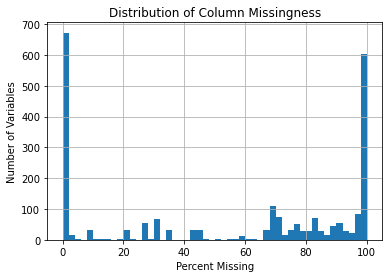

In [19]:
# Visualize missingness distribution
import matplotlib.pyplot as plt
missing_pct.hist(bins=50)

plt.title("Distribution of Column Missingness")
plt.xlabel("Percent Missing")
plt.ylabel("Number of Variables")

plt.show()

## Missingness Distribution Interpretation

The missingness distribution reveals strong sparsity polarization across the dataset.

The survey appears to contain:
1. a core group of relatively complete structural variables
2. a large collection of highly sparse conditional-response variables

This pattern is characteristic of complex household surveys where:
- respondents follow different questionnaire pathways
- some financial modules apply only to specific subgroups
- survey branching logic controls question visibility

From a machine learning perspective, this has several important implications:

- not all variables should be retained
- highly sparse variables may contribute limited predictive value
- feature governance will be essential
- preprocessing pipelines must handle structured missingness systematically
- dimensionality reduction may become necessary
- aggressiv feature filtering will likely improve the project

# Duplicate Respondent Audit

Before proceeding to preprocessing and modeling, the dataset is audited for duplicate respondent records.

Duplicate observations can:
- distort subgroup analysis
- bias machine learning models
- inflate performance metrics
- reduce stakeholder trust

The FinAccess dataset contains interview-level identifiers that can be used to validate respondent uniqueness.

In [20]:
# Check duplicated interview identifiers

df["interview__id"].duplicated().sum()

0

## Duplicate Audit Observations

No duplicated interview identifiers were detected in the dataset.

This suggests that:
- each row represents a unique respondent interview
- respondent integrity is preserved
- the dataset is structurally suitable for downstream machine learning workflows

This is important because duplicate respondent records could otherwise:
- bias predictive modeling
- distort subgroup analysis
- artificially inflate model performance

# Administrative & Identifier Variable Audit

Large survey datasets often contain administrative and identifier variables used for:
- respondent tracking
- survey operations
- data collection logistics
- household management

These variables are usually not appropriate for machine learning modeling because they:
- do not represent meaningful behavioral characteristics
- may introduce noise
- may accidentally leak information
- reduce explainability and deployment realism

This section identifies administrative and identifier variables that may later require exclusion from modeling workflows.

In [21]:
# Inspect likely administrative variables

admin_cols = [
    "Serial Number",
    "ClusterNo",
    "HHNo",
    "interview__key",
    "interview__id"
]

df[admin_cols].head()

,Serial Number,ClusterNo,HHNo,interview__key,interview__id
0,1,10226038,1048,10-67-89-46,0003fc74b3fe418ea041bd6a9e7ff387
1,2,10240034,1080,39-64-68-81,0004890b17744272baf0a0c7b4c20771
2,3,10216062,1013,92-34-74-01,00052153fe8c4abaa189caadcb87b2b4
3,4,10242078,1026,08-14-22-63,000d1f8747194b6a84862830dc5fe7ca
4,5,10219138,1019,99-12-05-84,000f5a5c0e3246ac9a62603ad936e3da


## Administrative Variable Observations

Several variables appear to function primarily as:
- respondent identifiers
- household identifiers
- survey tracking fields
- administrative collection variables

Examples include:
- interview identifiers
- cluster numbers
- household numbers
- serial tracking values

These variables are unlikely to represent meaningful socioeconomic behavior and may later require exclusion from machine learning modeling workflows.

# Identifier Cardinality Inspection

The uniqueness of administrative variables is inspected to determine whether they contain:
- near-unique identifiers
- high-cardinality values
- low generalization potential

High-cardinality identifiers are usually poor machine learning features because they:
- increase dimensionality
- reduce explainability
- encourage memorization rather than learning

In [22]:
# Count unique values for identifier variables

for col in admin_cols:
    print(f"{col}: {df[col].nunique()}")

Serial Number: 22024
ClusterNo: 1676
HHNo: 254
interview__key: 22024
interview__id: 22024


## Identifier Cardinality Interpretation

Several administrative variables contain fully unique values across respondents, including:
- Serial Number
- interview__key
- interview__id

These variables function primarily as respondent-level identifiers rather than meaningful socioeconomic predictors.

Including fully unique identifiers in machine learning models may:
- encourage memorization
- reduce generalization quality
- increase dimensionality unnecessarily
- weaken explainability

The ClusterNo variable appears partially grouped rather than fully unique, suggesting that it may represent survey sampling clusters or geographic aggregation structures.

This variable may potentially contain contextual socioeconomic information and may require additional investigation before exclusion decisions are made.

# Initial Leakage Risk Audit

One of the most important risks in machine learning projects is target leakage.

Target leakage occurs when predictor variables directly or indirectly contain information about the outcome being predicted.

The FinAccess survey already appears to contain:
- engineered financial-access indicators
- exclusion summary variables
- grouped inclusion categories
- post-survey derived financial classifications

If such variables are used during modeling, the model may effectively “see the answer” during training, producing:
- unrealistic performance
- misleading evaluation metrics
- weak generalization
- non-deployable systems

This section performs an initial audit of variables that may introduce leakage risk.

In [23]:
# Keywords associated with possible leakage variables

potential_leakage_keywords = [
    "banked",
    "excluded",
    "formal",
    "informal",
    "insurance",
    "nhif",
    "loan",
    "credit",
    "saving"
]

# Identify potentially risky columns

potential_leakage_cols = [
    col for col in df.columns
    if any(
        keyword.lower() in col.lower()
        for keyword in potential_leakage_keywords
    )
]

len(potential_leakage_cols)

76

In [24]:
# Preview potential leakage variables

potential_leakage_cols[:50]

['savings_usage',
 'savings_formal',
 'savings_informal',
 'savings_excluded',
 'loan_usage',
 'loan_formal',
 'loan_informal',
 'loan_formal_2',
 'loan_mbanking_2',
 'loan_fuliza_2',
 'loan_app_2',
 'savings_mbanking_2',
 'savings_mmoney_2',
 'savings_formal2',
 'tot_saving',
 'insurance_usage',
 'insurance_usage2',
 'insurance_usage1',
 'nhif_usage',
 'digital_app_loan',
 'formal_digital_sav',
 'formal_non_digital_sav',
 'formal_digital_loan',
 'formal_non_digital_loan',
 'tot_formal_digit_loan_sav',
 'tot_formal_non_digit_loan_sav',
 'formal_prudential',
 'formal_non_prudential',
 'formal_registered',
 'formal',
 'formal_other',
 'informal',
 'Digital_credit',
 'formal_service_use',
 'formal_fullservice_use',
 'noofloans',
 'noofloans_new',
 'currentloan',
 'defaultloan',
 'comp_noofloans',
 'formal_prudential_ever',
 'formal_non_prudential_ever',
 'formal_registered_ever',
 'formal_ever',
 'formal_other_ever',
 'informal_ever',
 'excludedpop_ever',
 'accessformal',
 'informal2',
 '

## Leakage Risk Observations

The audit identified a large number of variables directly related to:
- financial access
- savings participation
- credit usage
- insurance participation
- formal and informal financial service usage

Several variables appear to summarize or directly encode financial inclusion outcomes, including:
- formal access indicators
- exclusion summaries
- savings participation variables
- digital financial usage indicators
- insurance participation measures

These variables represent high leakage risk because they may already contain information closely related to the target outcome.

Using such variables during machine learning modeling could produce:
- artificially high model performance
- unrealistic predictive power
- poor deployment generalization
- weak interpretability

This confirms that strong feature governance will be essential before target engineering and model training.

# Leakage Severity Categorization

Not all financial-related variables represent the same level of leakage risk.

Some variables:
- directly encode exclusion outcomes
- summarize financial access status
- represent post-survey engineered indicators

Others may contain:
- partial behavioral information
- contextual financial activity
- indirect socioeconomic signals

This section categorizes variables according to their potential leakage severity in order to support:
- safe target engineering
- trustworthy preprocessing
- explainable modeling
- deployment realism

In [25]:
# Manually categorize leakage severity

high_risk_leakage = [
    "formal",
    "formal_ever",
    "formal_service_use",
    "formal_fullservice_use",
    "accessformal",
    "excludedpop_ever",
    "savings_usage",
    "loan_usage",
    "insurance_usage",
    "insurance_usage1",
    "insurance_usage2"
]

moderate_risk_variables = [
    "Digital_credit",
    "digital_app_loan",
    "currentloan",
    "defaultloan",
    "credit_Inst",
    "tot_saving",
    "noofloans"
]

print("High Risk Leakage Variables:")
print(high_risk_leakage)

print("\nModerate Risk Variables:")
print(moderate_risk_variables)

High Risk Leakage Variables:
['formal', 'formal_ever', 'formal_service_use', 'formal_fullservice_use', 'accessformal', 'excludedpop_ever', 'savings_usage', 'loan_usage', 'insurance_usage', 'insurance_usage1', 'insurance_usage2']

Moderate Risk Variables:
['Digital_credit', 'digital_app_loan', 'currentloan', 'defaultloan', 'credit_Inst', 'tot_saving', 'noofloans']


## Leakage Severity Interpretation

The leakage audit suggests that variables fall into different governance categories.

### High-Risk Leakage Variables
These variables directly summarize:
- formal financial access
- exclusion status
- financial participation outcomes

Such variables are likely unsuitable for predictive modeling because they already contain information closely related to the target outcome.

### Moderate-Risk Variables
These variables may reflect:
- behavioral financial activity
- contextual financial behavior
- indirect socioeconomic characteristics

These variables require additional evaluation before determining whether they are appropriate for modeling.

This categorization establishes an important governance framework for Notebook 02, where safe target engineering and predictor selection will be performed.

# Survey Domain Categorization

The FinAccess survey contains thousands of variables spanning multiple socioeconomic and behavioral domains.

To improve:
- feature governance
- interpretability
- explainability
- stakeholder communication
- downstream analysis

variables are grouped into broad analytical domains.

This domain structure will later support:
- exploratory data analysis
- feature engineering
- subgroup vulnerability analysis
- explainable AI interpretation
- deployment intelligence reporting

In [26]:
# Create high-level survey domains

survey_domains = {
    
    "demographic": [
        "A10i",   # gender
        "age",
        "marital_status",
        "education"
    ],
    
    "geographic": [
        "County",
        "ClusterNo",
        "A9"      # rural/urban
    ],
    
    "household": [
        "HHNo",
        "adults"
    ],
    
    "financial_access": [
        "formal",
        "informal",
        "excludedpop_ever",
        "formal_service_use"
    ],
    
    "savings_credit": [
        "savings_usage",
        "loan_usage",
        "currentloan",
        "defaultloan"
    ],
    
    "insurance": [
        "insurance_usage",
        "NHIF_health_insurance",
        "NHIFMedical_Cat"
    ],
    
    "digital_finance": [
        "Digital_credit",
        "digital_app_loan"
    ]
}

survey_domains.keys()

dict_keys(['demographic', 'geographic', 'household', 'financial_access', 'savings_credit', 'insurance', 'digital_finance'])

In [27]:
# Display survey domains

for domain, variables in survey_domains.items():
    print(f"\n{domain.upper()}")
    print(variables)


DEMOGRAPHIC
['A10i', 'age', 'marital_status', 'education']

GEOGRAPHIC
['County', 'ClusterNo', 'A9']

HOUSEHOLD
['HHNo', 'adults']

FINANCIAL_ACCESS
['formal', 'informal', 'excludedpop_ever', 'formal_service_use']

SAVINGS_CREDIT
['savings_usage', 'loan_usage', 'currentloan', 'defaultloan']

INSURANCE
['insurance_usage', 'NHIF_health_insurance', 'NHIFMedical_Cat']

DIGITAL_FINANCE
['Digital_credit', 'digital_app_loan']


## Survey Domain Structure Observations

The survey variables can be organized into several important analytical domains, including:
- demographic characteristics
- geographic structure
- household composition
- financial access indicators
- savings and credit behavior
- insurance participation
- digital finance behavior

This organizational structure improves:
- feature governance
- stakeholder communication
- explainability
- downstream exploratory analysis

It also establishes a foundation for:
- subgroup vulnerability analysis
- policy-oriented insights
- explainable AI reporting

# Initial Modeling Direction

The survey audit and structural analysis reveal that the FinAccess dataset is:
- highly dimensional
- heavily categorical
- structurally sparse
- metadata-dependent
- potentially leakage-prone

These findings strongly influence the modeling strategy for the project.

The project will therefore prioritize:
- leakage-aware target engineering
- safe predictor selection
- explainable preprocessing pipelines
- dimensionality governance
- stakeholder-oriented interpretability

Rather than modeling all variables directly, the project will focus on identifying:
- trustworthy structural predictors
- meaningful socioeconomic signals
- interpretable vulnerability indicators

The next notebook will focus on:
- cleaning
- target engineering
- leakage control
- safe feature selection
- preprocessing preparation

# Proposed Modeling Philosophy

The proposed machine learning system aims to predict financial exclusion risk using structural socioeconomic characteristics rather than direct financial outcome indicators.

The modeling philosophy emphasizes:
- explainability
- deployment realism
- leakage prevention
- stakeholder trust
- policy relevance

The project will prioritize models that balance:
- predictive performance
- interpretability
- fairness
- operational usefulness

Potential modeling approaches include:
- Logistic Regression
- Random Forest
- Gradient Boosting
- XGBoost

Explainability techniques such as SHAP will later be used to:
- identify key exclusion drivers
- understand subgroup vulnerabilities
- support policy-oriented recommendations

# Summary

This notebook performed a foundational audit of the FinAccess 2021 survey system.

Key findings include:

- the dataset contains 22,024 respondent records and 2,332 variables
- the survey is highly categorical and metadata-dependent
- substantial structural sparsity exists due to branching survey logic
- many variables represent engineered financial-access indicators
- several variables present serious target leakage risk
- administrative identifiers require governance before modeling
- feature selection and dimensionality reduction will be essential

The notebook established the governance foundation for the entire project by:
- auditing survey architecture
- understanding metadata systems
- identifying leakage-sensitive variables
- categorizing survey domains
- defining a trustworthy modeling philosophy

These findings now prepare the project for Notebook 02, where:
- safe target engineering
- leakage-aware feature selection
- preprocessing design
- reproducible artifact creation
will be performed.